In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import joblib
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

2026-02-15 10:26:41.490063: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-15 10:26:42.113743: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-15 10:26:44.576313: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/joe/miniconda3/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.p

## ML

In [2]:
# Target: (1,41.0, -109.0) -> Closest point:   71 with distance: 0.00 km
# Target: (5,41.0, -105.0) -> Closest point:  111 with distance: 0.00 km
# Target: (8,41.0, -102.0) -> Closest point:  141 with distance: 0.00 km
# Target: (17,39.0, -109.0) -> Closest point: 1491 with distance: 0.00 km
# Target: (21,39.0, -105.0) -> Closest point: 1531 with distance: 0.00 km
# Target: (24,39.0, -102.0) -> Closest point: 1561 with distance: 0.00 km
# Target: (33,37.0, -109.0) -> Closest point: 2911 with distance: 0.00 km
# Target: (37,37.0, -105.0) -> Closest point: 2951 with distance: 0.00 km
# Target: (40,37.0, -102.0) -> Closest point: 2981 with distance: 0.00 km
lat_lons = [
    [41.0, -109.0,1,71], [41.0, -105.0,5,111], [41.0, -102.0,8,141],
    [39.0, -109.0,17,1491], [39.0, -105.0,21,1531], [39.0, -102.0,24,1561],
    [37.0, -109.0,33,2911], [37.0, -105.0,37,2951], [37.0, -102.0,40,2981]    
            ]
xx=8
TARGET_COL = "VPD"  
TARGET_COL = "T"        # change to 
      # change to 

point_ML = lat_lons[xx][3]
point_EC = lat_lons[xx][2]
lat=lat_lons[xx][0]
lon = lat_lons[xx][1]

print(f"Running for point {point_ML} (lat={lat}, lon={lon}) with EC target {point_EC}")
"""
train_regime_model.py
---------------------
Train ONE regime model with horizon as a feature.
Model type is pluggable: Gradient Boosting or Neural Net.

This script:
- Uses deseasonalized  anomalies
- Trains on all horizons (1–12)
- Includes horizon explicitly as an input
- Trains ONE model for ONE target-month regime
"""


# =========================
# CONFIG
# =========================
CSV_PATH = Path(f"full_data_point_{point_ML}.csv")
DATE_COL = "Yrmo"          # YYYYMM


MAX_HORIZON = 12
MODEL_TYPE = "nn"          # "gb" or "nn"

#REGIME_NAME = "oct"
#REGIME_MONTHS = {10}        # October

FEATURE_COLS = ["F1","F2","F3","F4","F5","F6"]        # set explicitly or auto-detect

RANDOM_STATE = 42
REGIME_DEFS = {
    "jan": {1},
    "feb": {2},
    "mar": {3},
    "apr": {4},
    "may": {5},
    "jun": {6},
    "jul": {7},
    "aug": {8},
    "sep": {9},
    "oct": {10},
    "nov": {11},
    "dec": {12},
}

all_results = []


# =========================
# LOAD DATA
# =========================
df = pd.read_csv(CSV_PATH)
def c_to_f(c):
    return c * 9/5 + 32
df['T']=df['T'].apply(c_to_f)
df['Td']=df['Td'].apply(c_to_f)
df["date"] = pd.to_datetime(df[DATE_COL].astype(str) + "01", format="%Y%m%d")
df["month"] = df["date"].dt.month
df = df.sort_values("date").reset_index(drop=True)

if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found")

# =========================
# CALCULATE MONTHLY STATS FOR NORMALIZATION
# =========================

monthly_stats_por = (
    df.assign(month=df["Yrmo"] % 100)
      .groupby("month")[TARGET_COL]
      .agg(mean="mean", std="std")
)

print("Monthly stats (full POR):")
print(monthly_stats_por)
# =========================
# DESEASONALIZE TARGET
# =========================
monthly_mean = df.groupby("month")[TARGET_COL].mean()
df["target_anom"] = df[TARGET_COL] - df["month"].map(monthly_mean)

# =========================
# FEATURE SELECTION
# =========================
if FEATURE_COLS is None:
    exclude = {
        DATE_COL, "date", "month",
        TARGET_COL, "target_anom"
    }
    FEATURE_COLS = [
        c for c in df.columns
        if c not in exclude and pd.api.types.is_numeric_dtype(df[c])
    ]

if not FEATURE_COLS:
    raise RuntimeError("No numeric feature columns found")

print(f"Using {len(FEATURE_COLS)} features:")
print(FEATURE_COLS)

for REGIME_NAME, REGIME_MONTHS in REGIME_DEFS.items():

    print(f"\n=== Running regime: {REGIME_NAME} ===")
    
    # =========================
    # SCALE FEATURES & TARGET
    # =========================
    x_scaler = StandardScaler()
    X_all = x_scaler.fit_transform(df[FEATURE_COLS].values.astype(np.float32))

    y_scaler = StandardScaler()
    y_all = y_scaler.fit_transform(
        df[["target_anom"]].values.astype(np.float32)
    ).ravel()

    # =========================
    # BUILD SUPERVISED PAIRS
    # =========================
    X_list = []
    y_list = []
    meta_month = []
    meta_horizon = []
    n = len(df)
    meta_date = []
    for t in range(n):
        x_t = X_all[t]

        for h in range(1, MAX_HORIZON + 1):
            j = t + h
            if j >= n:
                continue

            target_month = int(df.loc[j, "month"])
            if target_month not in REGIME_MONTHS:
                continue

            # horizon as feature (scaled)
            h_feat = np.array([h / MAX_HORIZON], dtype=np.float32)

            X_list.append(np.concatenate([x_t, h_feat]))
            y_list.append(y_all[j])
            meta_month.append(target_month)
            meta_horizon.append(h)
            meta_date.append(df.loc[j, "date"])

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    meta_month = np.array(meta_month)
    meta_horizon = np.array(meta_horizon)
    meta_date = np.array(meta_date)

    print(f"\nBuilt dataset for regime '{REGIME_NAME}':")
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")

    if len(y) < 100:
        print("⚠️ WARNING: Very few training samples for this regime")

    # =========================
    # TRAIN / VALIDATION SPLIT
    # =========================
    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=0.2,
        shuffle=False
    )
    split = int(0.8 * len(y))
    meta_month_val = meta_month[split:]
    meta_horizon_val = meta_horizon[split:]
    val_dates = meta_date[split:]

    # =========================
    # MODEL FACTORY
    # =========================

    def quantile_loss(tau):
        """
        Quantile (pinball) loss.
        tau = 0.5 → MAE
        tau > 0.5 → penalize underprediction more
        """
        def loss(y_true, y_pred):
            e = y_true - y_pred
            return tf.reduce_mean(tf.maximum(tau * e, (tau - 1) * e))
        return loss


        
    def build_two_head_nn(input_dim, tau=0.85):
        import tensorflow as tf
        from tensorflow.keras.layers import Input, Dense
        from tensorflow.keras.models import Model
        from tensorflow.keras.optimizers import Adam

        inputs = Input(shape=(input_dim,))

        # Shared representation
        x = Dense(32, activation="relu")(inputs)
        x = Dense(16, activation="relu")(x)

        # Head 1: mean prediction
        mean_out = Dense(1, name="mean")(x)

        # Head 2: upper-quantile prediction
        quantile_out = Dense(1, name="quantile")(x)

        model = Model(
            inputs=inputs,
            outputs=[mean_out, quantile_out]
        )

        model.compile(
            optimizer=Adam(1e-3),
            loss={
                "mean": "mae",
                "quantile": quantile_loss(tau)
            },
            loss_weights={
                "mean": 0.5,
                "quantile": 0.5
            }
        )

        return model


    # =========================
    # TRAIN MODEL
    # =========================
    model = build_two_head_nn(X_train.shape[1])

    model.fit(
        X_train,
        {
            "mean": y_train,
            "quantile": y_train
        },
        validation_data=(
            X_val,
            {
                "mean": y_val,
                "quantile": y_val
            }
        ),
        epochs=200,
        callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
        verbose=0
    )

    # # =========================
    # # EVALUATE MODEL  

    

# ============================================================
# Predict (two-headed model)
# ============================================================
# =========================
# MODEL PREDICTION
# =========================

    y_mean_pred, y_quantile_pred = model.predict(X_val)

    y_mean_pred = y_mean_pred.reshape(-1)
    y_quantile_pred = y_quantile_pred.reshape(-1)


    # ============================================================
    # Inverse-scale anomalies
    # ============================================================
    y_val_anom = y_scaler.inverse_transform(
        y_val.reshape(-1, 1)
    ).ravel()

    y_mean_pred_anom = y_scaler.inverse_transform(
        y_mean_pred.reshape(-1, 1)
    ).ravel()

    y_quantile_pred_anom = y_scaler.inverse_transform(
        y_quantile_pred.reshape(-1, 1)
    ).ravel()

    # plt.figure(figsize=(10,4))
    # plt.plot(y_val_anom, marker="o", linestyle="", alpha=0.6)
    # plt.axhline(0, linestyle="--")
    # plt.title("Validation Anomalies (y_val_anom) — Scatter by Index")
    # plt.ylabel("Anomaly ( units)")
    # plt.xlabel("Validation sample index")
    # plt.tight_layout()
    # plt.show()

    # ============================================================
    # Add monthly means back (physical )
    # ============================================================
    monthly_mean_dict = monthly_mean.to_dict()

    y_val_phys = np.array([
        y_val_anom[i] + monthly_mean_dict[meta_month_val[i]]
        for i in range(len(y_val_anom))
    ])

    y_mean_pred_phys = np.array([
        y_mean_pred_anom[i] + monthly_mean_dict[meta_month_val[i]]
        for i in range(len(y_mean_pred_anom))
    ])

    y_quantile_pred_phys = np.array([
        y_quantile_pred_anom[i] + monthly_mean_dict[meta_month_val[i]]
        for i in range(len(y_quantile_pred_anom))
    ])


    # ============================================================
    # Helper: full evaluation
    # ============================================================
    def evaluate_head(name, y_pred_phys, regime_months):
        errors = y_val_phys - y_pred_phys
        abs_errors = np.abs(errors)

        mae = abs_errors.mean()
        rmse = np.sqrt(np.mean(errors ** 2))
        
        # plt.scatter(y_val_phys, errors, alpha=0.4)
        # plt.axhline(0, linestyle="--")
        # plt.xlabel("Observed ")
        # plt.ylabel("Residual (Obs − Pred)")
        # plt.title("Residual vs Observed ")



        # print(regime_months.dtype)
        # print(type(regime_months[0]), regime_months[0])

    #   regime_mask = np.isin( np.array(regime_months),meta_month_val)
        regime_mask = np.zeros_like(meta_month_val, dtype=bool)
        for m in REGIME_MONTHS:
            regime_mask |= (meta_month_val == m)



        regime_mae = abs_errors[regime_mask].mean() if regime_mask.any() else np.nan

        rank_corr = np.nan
        if regime_mask.sum() > 2:
            obs = y_val_phys[regime_mask]
            pred = y_pred_phys[regime_mask]
            obs_rank = np.argsort(np.argsort(obs))
            pred_rank = np.argsort(np.argsort(pred))
            rank_corr = np.corrcoef(obs_rank, pred_rank)[0, 1]

        q90 = np.percentile(y_val_phys, 90)
        extreme_mask = y_val_phys >= q90
        extreme_bias = (
            np.mean(y_pred_phys[extreme_mask] - y_val_phys[extreme_mask])
            if extreme_mask.any() else np.nan
        )
        por_std = np.mean([monthly_stats_por.loc[m, "std"] for m in REGIME_MONTHS])
        por_mn = np.mean([monthly_stats_por.loc[m, "mean"] for m in REGIME_MONTHS])

        nmanmn = mae / por_mn
        nmanstd = mae / por_std
        


        return {
            "POR_STD": por_std,
            "POR_MEAN": por_mn,
            "MAE": mae,
            "MAE_over_mean": nmanmn,
            "MAE_over_std": nmanstd,
            "RMSE": rmse,
            "Regime_MAE": regime_mae,
            "Regime_Rank": rank_corr,
            "Extreme_Bias": extreme_bias
        }


    # ============================================================
    # Run evaluation
    # ============================================================
    mean_metrics = evaluate_head("MEAN", y_mean_pred_phys, REGIME_MONTHS)
    quantile_metrics = evaluate_head("QUANTILE", y_quantile_pred_phys, REGIME_MONTHS)
    



    # ============================================================
    # SIDE-BY-SIDE SUMMARY
    # ============================================================
    fout=open(f"{REGIME_NAME}_delta_{TARGET_COL}_resid.txt","w")

    fout.write(f"\n================ {REGIME_NAME.upper()} TWO-HEAD COMPARISON =================\n")
    fout.write(f"{'Metric':<20} {'Mean Head':>12} {'Quantile Head':>15}\n")
    fout.write("-" * 50 + "\n")

    for key in mean_metrics:
        fout.write(
            f"{key:<20} "
            f"{mean_metrics[key]:>12.3f} "
            f"{quantile_metrics[key]:>15.3f}\n"
        )

    # ============================================================
    # MAE BY HORIZON (OPTIONAL BUT IDENTICAL)
    # ============================================================
    print(f"\nMAE by Horizon (Mean vs Quantile):\n")
    # Containers for pooled August diagnostics
    all_delta = []
    all_abs_resid = []
    all_horizon = []
    horizon_stats = {}
    for h in sorted(np.unique(meta_horizon_val)):
        mask = meta_horizon_val == h

        # --- existing metrics (unchanged) ---
        resid_mean = y_val_phys[mask] - y_mean_pred_phys[mask]
        resid_quant = y_val_phys[mask] - y_quantile_pred_phys[mask]

        mae_mean = np.abs(resid_mean).mean()
        mae_quant = np.abs(resid_quant).mean()

        fout.write(
            f"  h={h:2d} → Mean={mae_mean:.3f} | Quantile={mae_quant:.3f}\n"
        )

        # ============================================================
        # NEW: Normalized MAE using FULL POR monthly std
        # ============================================================

        # Months corresponding to this horizon slice
        months_h = meta_month_val[mask]

        # Pull POR std for each sample (month-aware)
        por_std = np.array([
            monthly_stats_por.loc[m, "std"]
            for m in months_h
        ])

        por_mean = np.array([
            monthly_stats_por.loc[m, "mean"]
            for m in months_h
        ])

        # Safety mask (std should never be zero, but be defensive)
        valid = por_std > 0

        nmastd_mean = np.mean(
            np.abs(resid_mean[valid]) / por_std[valid]
        )

        nmastd_quant = np.mean(
            np.abs(resid_quant[valid]) / por_std[valid]
        )
        nmamn_mean = np.mean(
            np.abs(resid_mean[valid]) / por_mean[valid]
        )

        nmamn_quant = np.mean(
            np.abs(resid_quant[valid]) / por_mean[valid]
        )
        print(f"horizon {h} valid : {valid}  std: {por_std[valid]}  por: {por_std}")
        horizon_stats[int(h)] = {
        
        "mae_mean": float(mae_mean),      
        "nmastd_mean": float(nmastd_mean),
        "nmamn_mean": float(nmamn_mean),
        "mae_quant": float(mae_quant),
        "nmastd_quant": float(nmastd_quant),       
        "nmamn_quant": float(nmamn_quant),
        "n_samples": int(mask.sum())
    }


    
        # fout.write(
        #     f"        nMAE/std → Mean={nmae_mean:.3f} | Quantile={nmae_quant:.3f}\n"
        # )

    all_results.append({
            "regime": REGIME_NAME,
            "months": sorted(REGIME_MONTHS),
            "por_STD": por_std[0],
            "por_MEAN": por_mean[0],
            "mean_MAE": mean_metrics["Regime_MAE"],
            "mean_MAE_over_mean": mean_metrics["MAE_over_mean"],
            "mean_MAE_over_std": mean_metrics["MAE_over_std"],

            "quant_MAE": quantile_metrics["Regime_MAE"],
            "quant_MAE_over_mean": quantile_metrics["MAE_over_mean"],
            "quant_MAE_over_std": quantile_metrics["MAE_over_std"],

            "mean_Rank": mean_metrics["Regime_Rank"],
            "quant_Rank": quantile_metrics["Regime_Rank"],
            "mean_ExtremeBias": mean_metrics["Extreme_Bias"],
            "quant_ExtremeBias": quantile_metrics["Extreme_Bias"],
            "horizon_stats": horizon_stats
        })
            

    
    
    fout.close()

    # # =========================
    # # SAVE ARTIFACTS
    # # =========================
    # out_prefix = f"{REGIME_NAME}_{MODEL_TYPE}"

    # if MODEL_TYPE == "gb":
    #     joblib.dump(model, f"model_{out_prefix}.pkl")
    # else:
    #     model.save(f"model_{out_prefix}.h5")

    # joblib.dump(x_scaler, f"x_scaler_{REGIME_NAME}.pkl")
    # joblib.dump(y_scaler, f"y_scaler_{REGIME_NAME}.pkl")
    # joblib.dump(monthly_mean, "monthly_mean.pkl")

    # print("\n✅ Training complete")
    # print(f"Saved model_{out_prefix}")
all_results_df = pd.DataFrame(all_results)
all_results_df
all_results_df.to_csv("regime_model_results_summary.csv", index=False)

print("DONE DONE DONE")


Running for point 2981 (lat=37.0, lon=-102.0) with EC target 40
Monthly stats (full POR):
            mean       std
month                     
1      35.793498  3.601961
2      39.050853  4.598995
3      48.166766  3.681483
4      56.533852  3.208061
5      65.858919  3.038139
6      75.843774  3.439803
7      80.059633  2.568582
8      77.868523  2.961563
9      71.325299  3.330848
10     58.920143  3.194891
11     46.296153  4.085096
12     36.917671  3.590639
Using 6 features:
['F1', 'F2', 'F3', 'F4', 'F5', 'F6']

=== Running regime: jan ===

Built dataset for regime 'jan':
X shape: (408, 7)
y shape: (408,)


I0000 00:00:1771176412.961912   16149 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13713 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
2026-02-15 10:26:56.258411: I external/local_xla/xla/service/service.cc:163] XLA service 0x7d4534003250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-15 10:26:56.258459: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3080 Laptop GPU, Compute Capability 8.6
2026-02-15 10:26:56.297560: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-15 10:26:56.556803: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
I0000 00:00:1771176417.831992   16287 device_compiler.h:196] Compiled cluster using XLA!  Thi

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step

MAE by Horizon (Mean vs Quantile):

horizon 1 valid : [ True  True  True  True  True  True  True]  std: [3.60196057 3.60196057 3.60196057 3.60196057 3.60196057 3.60196057
 3.60196057]  por: [3.60196057 3.60196057 3.60196057 3.60196057 3.60196057 3.60196057
 3.60196057]
horizon 2 valid : [ True  True  True  True  True  True  True]  std: [3.60196057 3.60196057 3.60196057 3.60196057 3.60196057 3.60196057
 3.60196057]  por: [3.60196057 3.60196057 3.60196057 3.60196057 3.60196057 3.60196057
 3.60196057]
horizon 3 valid : [ True  True  True  True  True  True  True]  std: [3.60196057 3.60196057 3.60196057 3.60196057 3.60196057 3.60196057
 3.60196057]  por: [3.60196057 3.60196057 3.60196057 3.60196057 3.60196057 3.60196057
 3.60196057]
horizon 4 valid : [ True  True  True  True  True  True  True]  std: [3.60196057 3.60196057 3.60196057 3.60196057 3.60196057 3.60196057
 3.60196057]  por: [3.60196057 3.60196057 3.60196057 3.60196057 3.60196057 3.60196057
 

## Sarima


In [3]:
def evaluate_sarima_monthly(
    df,TARGET_COL,FEATURE_COLS,
    date_col="Yrmo",
    order=(1, 0, 0),
    seasonal_order=(0, 1, 1, 12),
):
    """
    Drop-in SARIMA evaluation aligned with ML.

    - Uses RAW Observed (no scaling, no anomalies)
    - Uses EXACT ML train/test split
    - Computes MAE ONLY on test split
    - Produces MONTHLY MAE (Jan–Dec)

    Parameters
    ----------
    df : pandas.DataFrame
        Full dataset used by ML
    train_end_yrmo : int
        Last YYYYMM used for training (same as ML)

    date_col : str
        YYYYMM column
    order : tuple
        SARIMA (p,d,q)
    seasonal_order : tuple
        SARIMA (P,D,Q,s)

    Returns
    -------
    dict with:
        - total_mae
        - mae_by_month (pd.Series indexed 1–12)
        - sarima_model (fitted object)
    """

    import numpy as np
    import pandas as pd
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    X=df[FEATURE_COLS].values.astype(np.float32)
    y=df[TARGET_COL].values.astype(np.float32)
    # ------------------------------------------------------------------
    # 1. Exact ML train/test split
    # ------------------------------------------------------------------
    X_train, X_val, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        shuffle=False
    )

    # ------------------------------------------------------------------
    # 2. Fit SARIMA on TRAIN ONLY (raw)
    # ------------------------------------------------------------------
    model = SARIMAX(
        y_train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )

    res = model.fit(disp=False)

    # ------------------------------------------------------------------
    # 3. Forecast EXACT test window
    # ------------------------------------------------------------------
    y_pred = res.forecast(steps=len(y_test))

    # ------------------------------------------------------------------
    # 4. Compute MAE ONLY on test split
    # ------------------------------------------------------------------
    abs_err = np.abs(y_test - y_pred)
    total_mae = abs_err.mean()

    # ------------------------------------------------------------------
    # 5. Monthly MAE (target-month based)
    # ------------------------------------------------------------------
    test_df = df[len(y_train):].copy()
    test_df["abs_err"] = abs_err
    test_df["month"] = test_df[date_col] % 100

    mae_by_month = (
        test_df
        .groupby("month")["abs_err"]
        .mean()
        .sort_index()
    )

    return {
        "total_mae": total_mae,
        "mae_by_month": mae_by_month,
        "sarima_model": res,
    }



sarima_results = evaluate_sarima_monthly(
    df=df,TARGET_COL=TARGET_COL,FEATURE_COLS=FEATURE_COLS, # EXACT ML cutoff
    order=(1, 0, 0),                 # <-- your existing SARIMA
    seasonal_order=(0, 1, 1, 12),    # <-- your existing SARIMA
)

print("SARIMA test MAE:", sarima_results["total_mae"])
print("\nSARIMA monthly MAE:")
print(sarima_results["mae_by_month"])

month_name={1:"jan",2:"feb",3:"mar",4:"apr",5:"may",6:"jun",7:"jul",8:"aug",9:"sep",10:"oct",11:"nov",12:"dec"}
sarima_full_results={}
for mnth,val in sarima_results['mae_by_month'].items():
    mnthNm=month_name[mnth]
    sarima_full_results[mnthNm]={}
    sarima_full_results[mnthNm]['mae']=val
    sarima_full_results[mnthNm]['mae_over_std']=val/monthly_stats_por.loc[mnth,'std']
    sarima_full_results[mnthNm]['mae_over_mean']=val/monthly_stats_por.loc[mnth,'mean']


all_results_full=[]
for reg in all_results:
    mnth = reg['regime']
    reg['sarima_results']=sarima_full_results[mnth]
    all_results_full.append(reg)

print(all_results_full)


SARIMA test MAE: 2.803904501241734

SARIMA monthly MAE:
month
1     2.121771
2     3.878774
3     2.595907
4     1.690359
5     2.849672
6     3.027990
7     0.997823
8     2.562853
9     3.429208
10    3.083177
11    3.184310
12    4.225011
Name: abs_err, dtype: float64
[{'regime': 'jan', 'months': [1], 'por_STD': np.float64(3.601960574827243), 'por_MEAN': np.float64(35.793497926267285), 'mean_MAE': np.float32(2.3048048), 'mean_MAE_over_mean': np.float64(0.06439171736410602), 'mean_MAE_over_std': np.float64(0.6398750774920574), 'quant_MAE': np.float32(2.4022634), 'quant_MAE_over_mean': np.float64(0.0671145191757279), 'quant_MAE_over_std': np.float64(0.666932175695471), 'mean_Rank': np.float64(0.04154286522784907), 'quant_Rank': np.float64(0.169904550451127), 'mean_ExtremeBias': np.float32(-3.5872552), 'quant_ExtremeBias': np.float32(-1.6302227), 'horizon_stats': {1: {'mae_mean': 2.503652572631836, 'nmastd_mean': 0.695080504247861, 'nmamn_mean': 0.0699471333533601, 'mae_quant': 2.22471

In [4]:
final=[]
for mon in all_results_full:
    for h in mon['horizon_stats']:
    #    print(h)
    #    print(mon['regime'],h,mon['horizon_stats'][h]['nmastd_mean'],mon['horizon_stats'][h]['nmastd_quant'],mon['sarima_results']['mae_over_std'])
        if mon['horizon_stats'][h]['nmastd_mean'] <= mon['horizon_stats'][h]['nmastd_quant']:
           mlV= mon['horizon_stats'][h]['nmastd_mean'] 
           mae= mon['horizon_stats'][h]['mae_mean']
           
           mlT = "MM"
        else:
           mlV= mon['horizon_stats'][h]['nmastd_quant'] 
           mlT = "QT"
           mae= mon['horizon_stats'][h]['mae_quant']


        if mon['sarima_results']['mae_over_std'] < mlV*.85:
           val= mon['sarima_results']['mae_over_std']
           model="SA"
           mae = mon['sarima_results']['mae']
        else:
           val= mlV
           model='ML'

        std=mon['por_STD']
        mn=mon['por_MEAN']
        print(f"{mon['regime']},{h},{val:.3f},{model}")
        tmp={
           "Month":mon['regime'],  
           "Horizon":h,
           "nMAE_over_std":float(val),
           "Best_Model":model,
           "MAE": mae,
           "por_STD":std,
           "por_MEAN":mn
        }
        final.append(tmp)

final_ML=pd.DataFrame(final)
final_ML['variable']=TARGET_COL
aML = final_ML.copy()


aML.rename(columns={ 'nMAE_over_std':'ML_MAE_over_std', 'Best_Model':'ML_Best_Model', 'MAE':'ML_MAE', 'por_STD':'ML_por_STD',
       'por_MEAN':'ML_por_MEAN'},inplace=True)



jan,1,0.618,ML
jan,2,0.486,ML
jan,3,0.608,ML
jan,4,0.563,ML
jan,5,0.654,ML
jan,6,0.583,ML
jan,7,0.595,ML
jan,8,0.598,ML
jan,9,0.653,ML
jan,10,0.655,ML
jan,11,0.611,ML
jan,12,0.656,ML
feb,1,0.764,ML
feb,2,0.720,ML
feb,3,0.761,ML
feb,4,0.735,ML
feb,5,0.785,ML
feb,6,0.658,ML
feb,7,0.721,ML
feb,8,0.667,ML
feb,9,0.649,ML
feb,10,0.648,ML
feb,11,0.879,ML
feb,12,0.861,ML
mar,1,0.486,ML
mar,2,0.647,ML
mar,3,0.726,ML
mar,4,0.645,ML
mar,5,0.739,ML
mar,6,0.642,ML
mar,7,0.568,ML
mar,8,0.741,ML
mar,9,0.755,ML
mar,10,0.528,ML
mar,11,0.634,ML
mar,12,0.553,ML
apr,1,0.527,SA
apr,2,0.575,ML
apr,3,0.527,SA
apr,4,0.598,ML
apr,5,0.583,ML
apr,6,0.537,ML
apr,7,0.407,ML
apr,8,0.600,ML
apr,9,0.575,ML
apr,10,0.406,ML
apr,11,0.615,ML
apr,12,0.386,ML
may,1,0.887,ML
may,2,0.727,ML
may,3,0.921,ML
may,4,0.832,ML
may,5,0.846,ML
may,6,0.861,ML
may,7,0.864,ML
may,8,0.879,ML
may,9,0.870,ML
may,10,0.948,ML
may,11,0.801,ML
may,12,0.693,ML
jun,1,0.935,ML
jun,2,0.997,ML
jun,3,0.975,ML
jun,4,0.759,ML
jun,5,0.966,ML
jun,6,0.88

## ECMWF Climate Model

In [5]:
ecmwf = pd.read_csv("ecmwfTTdRhVpdUVP.csv")
ecmwf.rename(columns={'t':'T',"td":"Td"},inplace=True)
ecmwf["T"]=ecmwf["T"].apply(c_to_f)
ecmwf["Td"]=ecmwf["Td"].apply(c_to_f)
ecmwf_obs = ecmwf.loc[ecmwf['forecastInterval']==0,['point','analysisDate',TARGET_COL]]


# Merge ecmwf with ecmwf_obs on matching dates
for idx, row in ecmwf.iterrows():
    forecast_date = row['forecastDate']
    point=row['point']
    matching_obs = ecmwf_obs[(ecmwf_obs['analysisDate'] == forecast_date) & (ecmwf_obs['point'] == point)]
    if not matching_obs.empty:
        ecmwf.at[idx, 'obs'] = matching_obs[TARGET_COL].values[0]    


ecmwf['error']=ecmwf['obs']-ecmwf[TARGET_COL]

ecmwf['abs error'] = np.abs(ecmwf['error'])
ecmwf['month'] = ecmwf['forecastDate'].str[:2].astype(int)


gp=ecmwf.groupby(['point','month','forecastInterval'],as_index=False)['abs error'].agg(['mean','std'])

gp.rename(columns={'mean':'mean_abs_error','std':'std_abs_error'},inplace=True)
gp['mae_over_std']=gp['mean_abs_error']/gp['std_abs_error']
print(gp.head())


final_model=gp.loc[gp['point']==    point_EC].copy()
month_name={1:"jan",2:"feb",3:"mar",4:"apr",5:"may",6:"jun",7:"jul",8:"aug",9:"sep",10:"oct",11:"nov",12:"dec"}
final_model['month']=final_model['month'].map(month_name)


   point  month  forecastInterval  mean_abs_error  std_abs_error  mae_over_std
0      1      1                 0           0.000       0.000000           NaN
1      1      1                 1           1.935       2.197707      0.880463
2      1      1                 2           2.295       2.539668      0.903661
3      1      1                 3           2.880       2.599560      1.107880
4      1      1                 4           2.430       2.606673      0.932223


In [6]:
ecmwf_obs.head(100)

,point,analysisDate,T
0,1,01/01/2017,12.56
6,1,02/01/2017,22.28
12,1,03/01/2017,26.60
18,1,04/01/2017,38.84
24,1,05/01/2017,52.88
...,...,...,...
570,1,12/01/2024,22.10
576,1,01/01/2025,18.14
582,1,02/01/2025,23.00
588,2,01/01/2017,13.46


## Full Analysis Good

In [7]:
ecmwf_means=ecmwf.groupby(['month','forecastInterval'],as_index=False)[[TARGET_COL,'obs','abs error']].agg(['mean','std'])

ecmwf_means.columns=['_'.join(map(str, col)).strip('_') for col in ecmwf_means.columns.values]

ecmwf_means= ecmwf_means.loc[ecmwf_means['forecastInterval'] > 0]
ecmwf_means.rename(columns={'month':'Month','forecastInterval':'Horizon','abs error_mean':'ECMWF_Mean_Abs_Error'},inplace=True)

month_name={1:"jan",2:"feb",3:"mar",4:"apr",5:"may",6:"jun",7:"jul",8:"aug",9:"sep",10:"oct",11:"nov",12:"dec"}
ecmwf_means['Month']=ecmwf_means['Month'].map(month_name)

all_means=pd.merge(aML,ecmwf_means,on=['Month','Horizon'],how='left')



37.0,-102.0,2981,40,1.8292208583097322,1.9550535714285713,17,43,0.7036178179130662,0.4922630390919755,2.4358919428596217,84,0.726886827442254


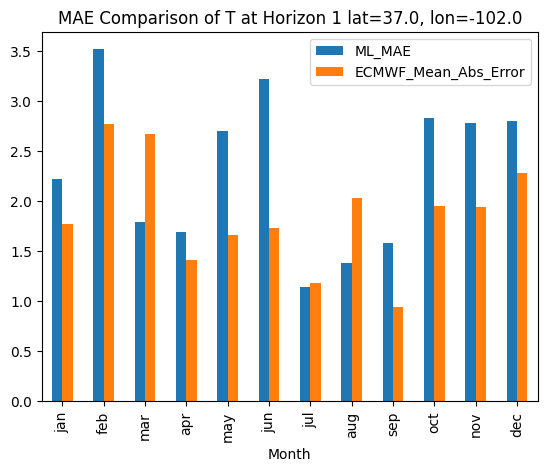

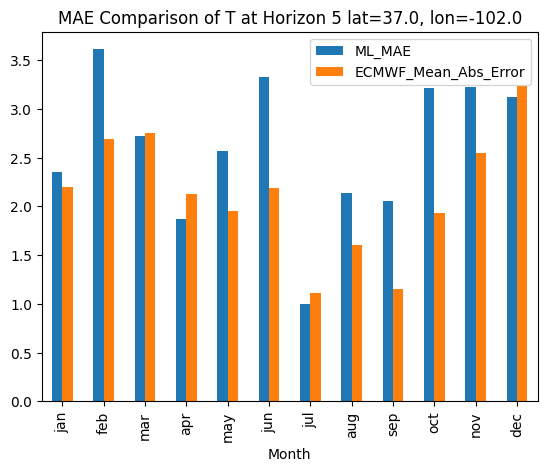

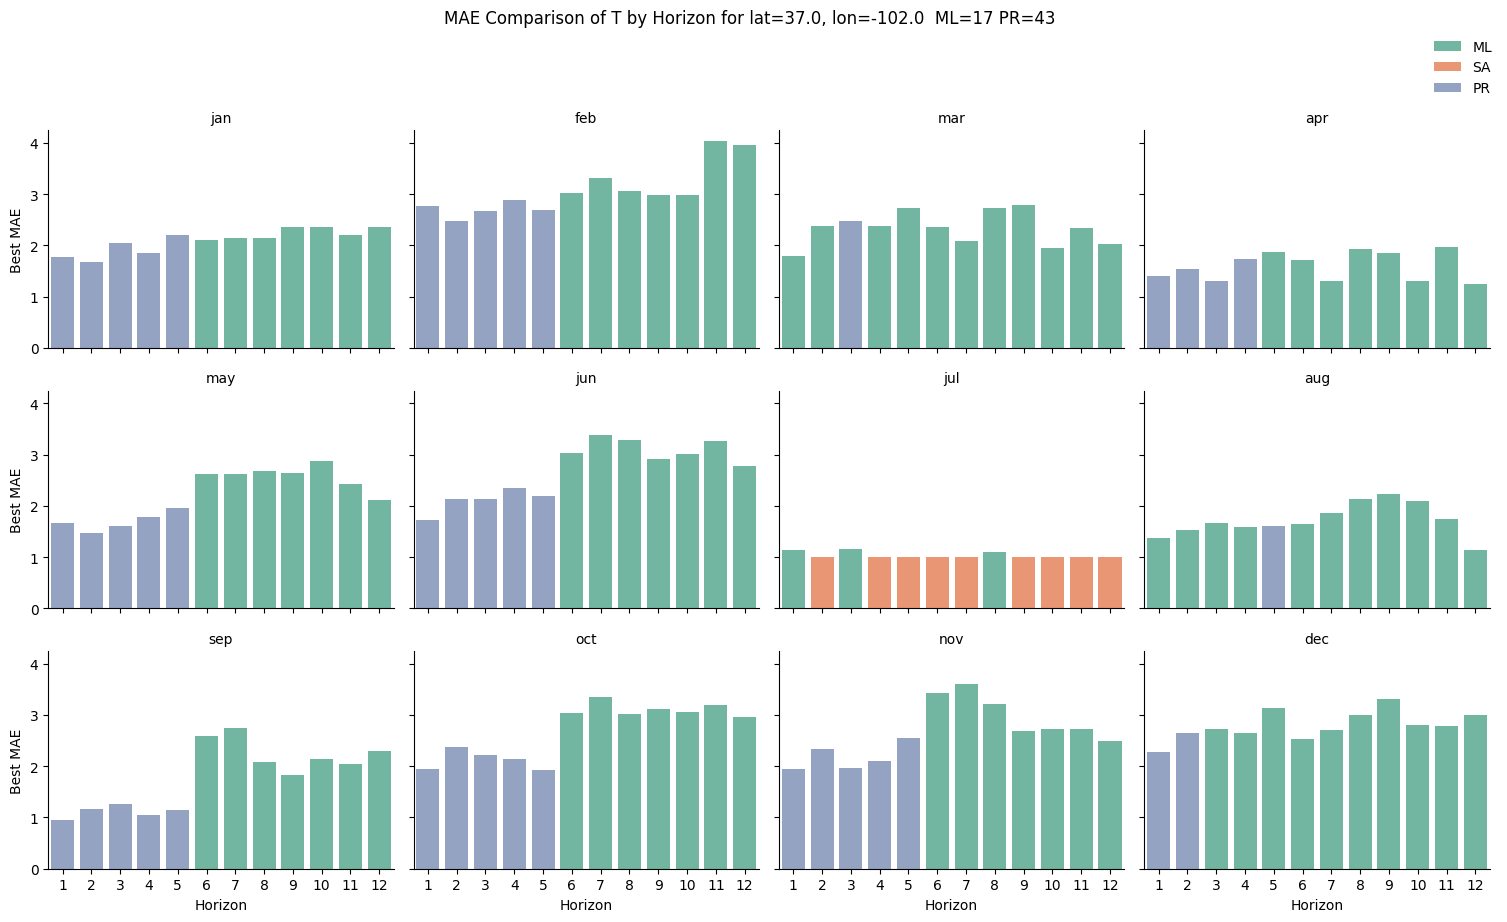

In [8]:
all_means.loc[all_means['Horizon'] == 1].plot(x='Month', y=['ML_MAE','ECMWF_Mean_Abs_Error'], kind='bar')
plt.title(f"MAE Comparison of {TARGET_COL} at Horizon 1 lat={lat}, lon={lon}")
plt.savefig(f"Plots/MAE_Analysis_{TARGET_COL}_Horizon_1_lat{lat}_lon{lon}.png")

all_means.loc[all_means['Horizon'] == 5].plot(x='Month', y=['ML_MAE','ECMWF_Mean_Abs_Error'], kind='bar')
plt.title(f"MAE Comparison of {TARGET_COL} at Horizon 5 lat={lat}, lon={lon}")
plt.savefig(f"Plots/MAE_Analysis_{TARGET_COL}_Horizon_5_lat{lat}_lon{lon}.png")
all_means['ML_norm_mae'] = all_means['ML_MAE']/all_means['ML_por_STD']
all_means['ECMWF_norm_mae'] = all_means['ECMWF_Mean_Abs_Error']/all_means['obs_std']                    



def compare_models(row,mlCol,modelCol):
    ml_mae_norm = row[mlCol]
    pr_mae_norm = row[modelCol]
    ml_mod = row['ML_Best_Model']
    hr = row['Horizon']
    if hr < 6:
        if pr_mae_norm < ml_mae_norm :
            row['Final Norm'] = pr_mae_norm
            row['Final Model'] = 'PR'
        else:
            row['Final Norm'] = ml_mae_norm
            row['Final Model'] = ml_mod
    else:
        row['Final Norm'] = ml_mae_norm
        row['Final Model'] = ml_mod
    return row
finalDf = all_means.apply(compare_models, axis=1,args=('ML_MAE', 'ECMWF_Mean_Abs_Error'))
#finalDf = all_means.apply(compare_models, axis=1,args=('ML_norm_mae_mean', 'ECMWF_norm_mae_mean'))

import seaborn as sns
import matplotlib.pyplot as plt
#finalDf=all_means.loc[all_means['Horizon'] < 6]

a=finalDf['Final Model'].value_counts().to_dict()
ML=a['ML'] + a['SA'] - 84
PR=a['PR']


# Create a FacetGrid with one column per month
g = sns.FacetGrid(
    finalDf,
    col="Month",
    col_wrap=4,  # 4 plots per row
    height=3,
    aspect=1.2
)

# Map a barplot to each facet
g.map_dataframe(
    sns.barplot,
    x="Horizon",
    y="Final Norm",
    hue="Final Model",
    hue_order=['ML', 'SA', 'PR'],  # Explicitly set all categories
    palette="Set2"
)

# Add legend and labels
g.add_legend(loc='upper right', bbox_to_anchor=(1, 1))
g.set_axis_labels("Horizon", "Best MAE")
g.set_titles("{col_name}")
plt.tight_layout()
#plt.stitle(f"Best Model MAE Comparison by Month and Horizon lat={lat}, lon={lon} ML={ML} PR={PR}", y=1.02)
#g.fig.suptitle(f"MAE Comparison by Horizon for lat={lat}, lon={lon}", y=1.02)

g.fig.suptitle(f"MAE Comparison of {TARGET_COL} by Horizon for lat={lat}, lon={lon}  ML={ML} PR={PR}", y=1.02)
g.tight_layout(rect=[0, 0, 1, 0.96])  # leave space for suptitle

g.fig.savefig(f"Plots/MAE_Analysis_by_Horizon_{TARGET_COL}_lat{lat}_lon{lon}.png", bbox_inches="tight")
# ...existing code...


#plt.savefig(f"Plots/MAE_Analysis_by_Horizon_lat{lat}_lon{lon}.png")

finalDf.to_csv(f"final_comparison_{TARGET_COL}_lat{lat}_lon{lon}.csv", index=False)
from pathlib import Path
finalDf['Final Model']=finalDf['Final Model'].map({'ML':'ML','SA':'ML','PR':'PR'})
a=finalDf[finalDf['Horizon'] < 6].groupby(['Final Model'])['Final Norm'].agg(['mean','std','count']).to_dict()
b=finalDf[finalDf['Horizon'] > 5].groupby(['Final Model'])['Final Norm'].agg(['mean','std','count']).to_dict()
print(f"{lat},{lon},{point_ML},{point_EC},{a['mean']['ML']},{a['mean']['PR']},{a['count']['ML']},{a['count']['PR']},{a['std']['ML']},{a['std']['PR']},{b['mean']['ML']},{b['count']['ML']},{b['std']['ML']}")


out_path = Path("summary_mae.csv")
write_header = not out_path.exists()

with open("summary_mae.csv", "a") as fout:
    if write_header:
        fout.write("variable,lat,lon,ML_Point,PR_Point,ML_Mean_MAE_1_5,PR_Mean_MAE_1_5,ML_Count_1_5,PR_Count_1_5,ML_Std_1_5,PR_Std_1_5,ML_Mean_MAE_6_12,ML_Count_6_12,ML_Std_6_12\n")
    fout.write(f"{TARGET_COL},{lat},{lon},{point_ML},{point_EC},{a['mean']['ML']:.4f},{a['mean']['PR']:.4f},{a['count']['ML']},{a['count']['PR']},{a['std']['ML']:.4f},{a['std']['PR']:.4f},{b['mean']['ML']:.4f},{b['count']['ML']},{b['std']['ML']:.4f}\n")



In [10]:
finalDf 

,Month,Horizon,ML_MAE_over_std,ML_Best_Model,ML_MAE,ML_por_STD,ML_por_MEAN,variable,T_mean,T_std,obs_mean,obs_std,ECMWF_Mean_Abs_Error,abs error_std,ML_norm_mae,ECMWF_norm_mae,Final Norm,Final Model
0,jan,1,0.617640,ML,2.224715,3.601961,35.793498,T,21.224187,6.749409,21.594875,6.82317,1.767937,1.785748,0.617640,0.259108,1.767937,PR
1,jan,2,0.486159,ML,1.751127,3.601961,35.793498,T,21.151625,6.656155,21.594875,6.82317,1.666125,1.728704,0.486159,0.244186,1.666125,PR
2,jan,3,0.607963,ML,2.189860,3.601961,35.793498,T,20.585750,6.654619,21.594875,6.82317,2.045250,1.840453,0.607963,0.299751,2.045250,PR
3,jan,4,0.562715,ML,2.026876,3.601961,35.793498,T,20.345000,6.431480,21.594875,6.82317,1.860750,1.770345,0.562715,0.272710,1.860750,PR
4,jan,5,0.654249,ML,2.356581,3.601961,35.793498,T,19.855625,6.348555,21.594875,6.82317,2.200500,2.104260,0.654249,0.322504,2.200500,PR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,dec,8,0.833640,ML,2.993299,3.590639,36.917671,T,NaN,NaN,NaN,NaN,NaN,NaN,0.833640,NaN,2.993299,ML
140,dec,9,0.920710,ML,3.305936,3.590639,36.917671,T,NaN,NaN,NaN,NaN,NaN,NaN,0.920710,NaN,3.305936,ML
141,dec,10,0.781840,ML,2.807303,3.590639,36.917671,T,NaN,NaN,NaN,NaN,NaN,NaN,0.781839,NaN,2.807303,ML
142,dec,11,0.774075,ML,2.779425,3.590639,36.917671,T,NaN,NaN,NaN,NaN,NaN,NaN,0.774075,NaN,2.779425,ML
